# Explorative Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

Let's import our raw price data

In [2]:
prices = pd.read_csv("../data/raw/prices_IT_2015_2024.csv", index_col=0, parse_dates=True)
prices.index = pd.to_datetime(prices.index, utc=True)

In [3]:
prices.name = 'price_eur_mwh'

                  0
count  78784.000000
mean      95.618858
std       98.919137
min        0.000000
25%       43.470000
50%       57.550000
75%      103.000000
max      871.000000
Negative value count: 0    0
dtype: int64
Over 400 EUR/MWh count: 0    2097
dtype: int64


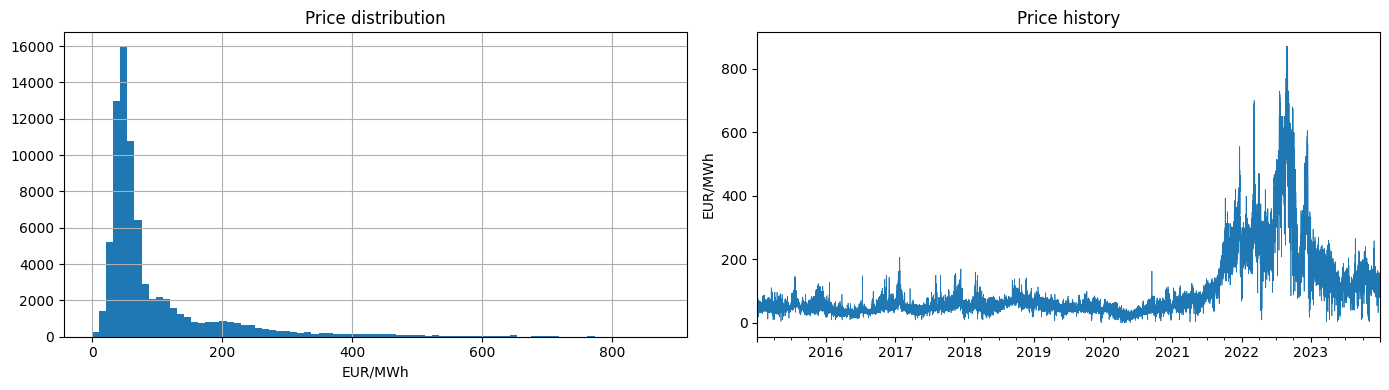

In [4]:
print(prices.describe())
print(f"Negative value count: {(prices < 0).sum()}")
print(f"Over 400 EUR/MWh count: {(prices > 400).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14,4))

prices.hist(bins=80, ax=axes[0], edgecolor='none')
axes[0].set_title("Price distribution")
axes[0].set_xlabel("EUR/MWh")

prices.plot(ax=axes[1], linewidth=0.5, label='Electricity prices', legend=False)
axes[1].set_title("Price history")
axes[1].set_ylabel("EUR/MWh")
plt.tight_layout()
plt.savefig('../data/processed/02_overview.png', dpi=150)

Prices significantly oscillates. The price distribution highlights three regimes around 50, 200 and 400 EUR/MWh, with a long tail on high prices.

Let's look for a periodic behaviour. Since price is determined on a demand and supply basis, we expect some periodic movement in the energy price: most of the demand is localized in the first few hours in the morning and the last hours of the evening, while it reaches it lowest values at night time. Other than intra-day fluctuations, electricity demand varies on a weekly (being lower on week ends) and on a seasonal basis (in winter and summer demands tends to be higher for heating and AC, compared to spring and autumn). On the other hand, supply is also subject to periodic dependencies. For example, solar power has an obvious daily and seasonal periodicity, but it's influenced by sky clearness as well, which can be periodic. Wind power is also seasonal, yet the dependency is less obvious than in the solar case.

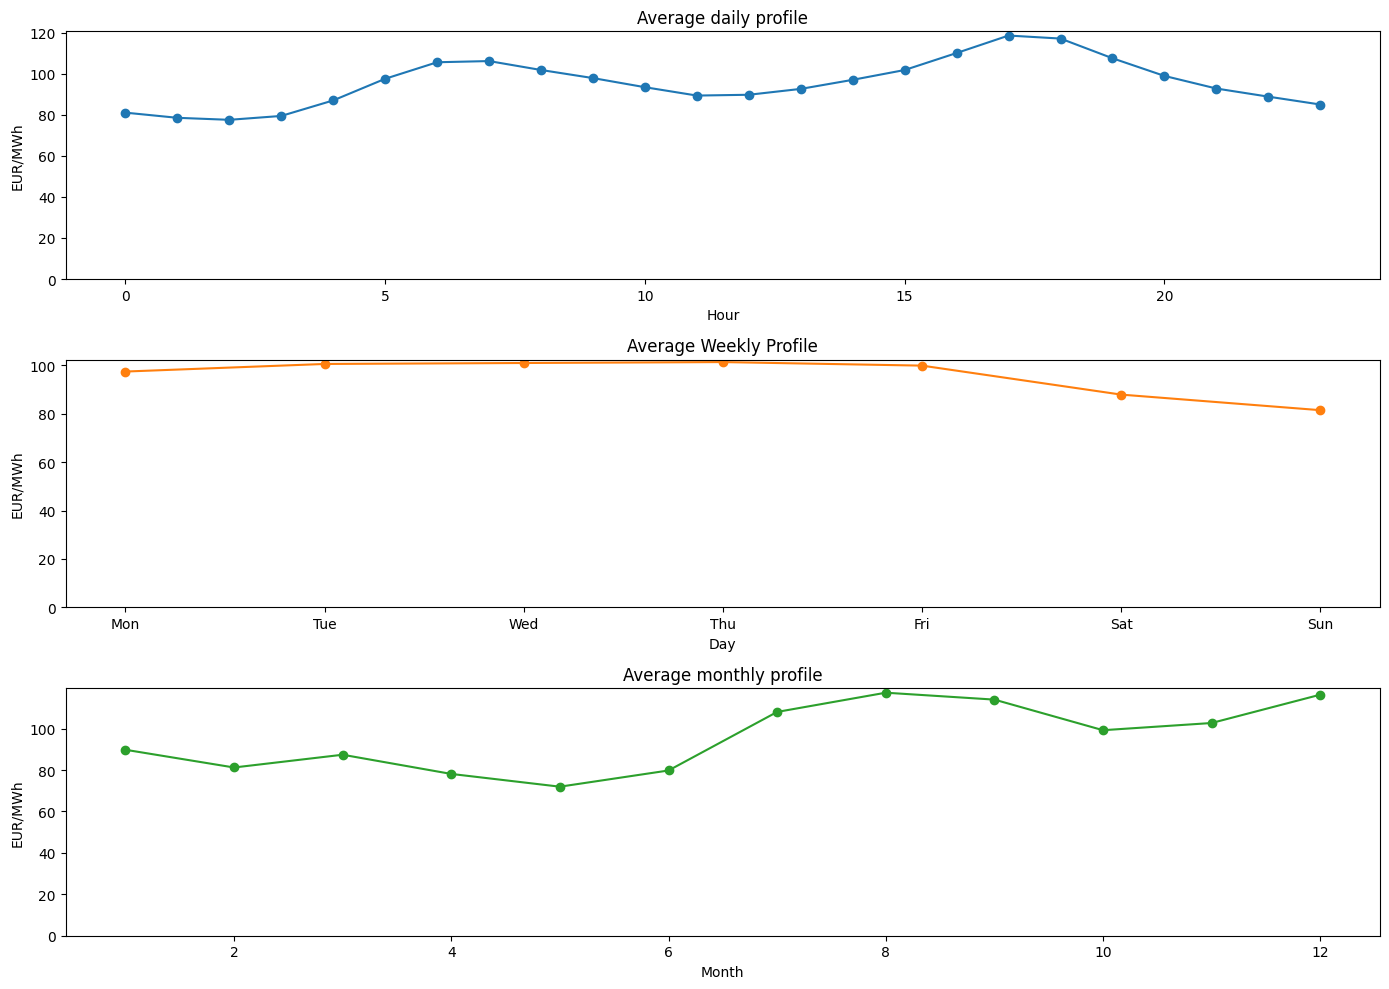

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14,10))

prices.groupby(prices.index.hour).mean().plot(
    ax=axes[0],
    marker='o',
    legend=False
)
axes[0].set_title("Average daily profile")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("EUR/MWh")
axes[0].set_ylim(0)

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
prices.groupby(prices.index.dayofweek).mean().plot(
    ax=axes[1],
    marker='o',
    color='C1',
    legend=False
)
axes[1].set_title("Average Weekly Profile")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("EUR/MWh")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_ylim(0)

prices.groupby(prices.index.month).mean().plot(
    ax=axes[2],
    marker='o',
    color='C2',
    legend=False
)
axes[2].set_title("Average monthly profile")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("EUR/MWh")
axes[2].set_ylim(0)

plt.tight_layout()
plt.savefig('../data/processed/02_periodic_profiles.png')

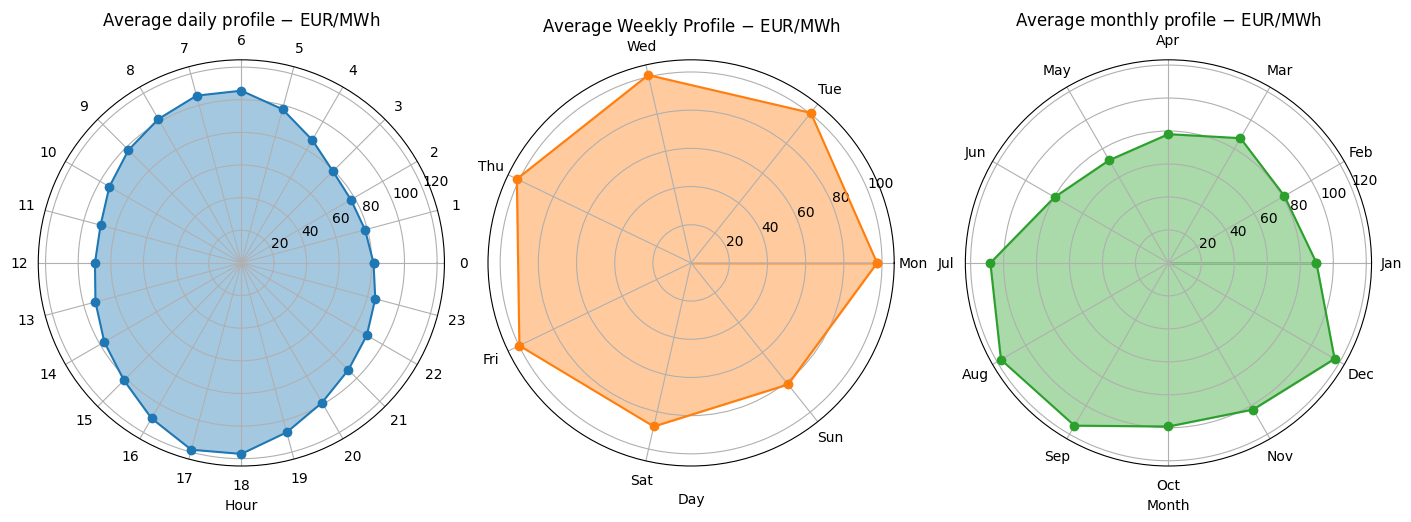

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14,6), subplot_kw={'projection': 'polar'}, layout='constrained')


daily_prices = prices.groupby(prices.index.hour).mean().values
daily_prices = np.append(daily_prices, daily_prices[0])
axes[0].plot(
    [x * (2 * np.pi / 24) for x in range(25)],
    daily_prices,
    marker='o',
)
axes[0].fill_between(
    [x * (2 * np.pi / 24) for x in range(25)],
    daily_prices,
    alpha=0.4)
axes[0].set_title("Average daily profile $-$ EUR/MWh")
axes[0].set_xlabel("Hour")
# axes[0].set_ylabel("EUR/MWh")
axes[0].set_xticks([x * (2 * np.pi / 24) for x in range(24)])
axes[0].set_xticklabels(range(24))

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
# prices.groupby(prices.index.dayofweek).mean().plot(
#     ax=axes[1],
#     marker='o',
#     color='coral'
# )
weekly_prices = prices.groupby(prices.index.dayofweek).mean().values
weekly_prices = np.append(weekly_prices, weekly_prices[0])
axes[1].plot(
    [x * 2 * np.pi / 7 for x in range(8)],
    weekly_prices,
    marker='o',
    color='C1'
)
axes[1].fill_between(
    [x * (2 * np.pi / 7) for x in range(8)],
    weekly_prices,
    color='C1',
    alpha=0.4)
axes[1].set_title("Average Weekly Profile $-$ EUR/MWh")
axes[1].set_xlabel("Day")
# axes[1].set_ylabel("EUR/MWh")
axes[1].set_xticks([x * 2 * np.pi / 7 for x in range(7)])
axes[1].set_xticklabels(day_names)

monthly_prices = prices.groupby(prices.index.month).mean().values
monthly_prices = np.append(monthly_prices, monthly_prices[0])

axes[2].plot(
    [x * 2 * np.pi / 12 for x in range(13)],
    monthly_prices,
    marker='o',
    color='C2'
)
axes[2].fill_between(
    [x * (2 * np.pi / 12) for x in range(13)],
    monthly_prices,
    color='C2',
    alpha=0.4)
axes[2].set_title("Average monthly profile $-$ EUR/MWh")
axes[2].set_xlabel("Month")
# axes[2].set_ylabel("EUR/MWh")
axes[2].set_xticks([x * 2 * np.pi / 12 for x in range(12)])
axes[2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# plt.tight_layout()
plt.savefig('../data/processed/02_periodic_profiles_radial.png')

As expected, periodic fluctuations of energy prices are observed on a daily, weekly and montlhy basis. To dive further into the daily and weekly price dependence, let's show an hour x day heat map.

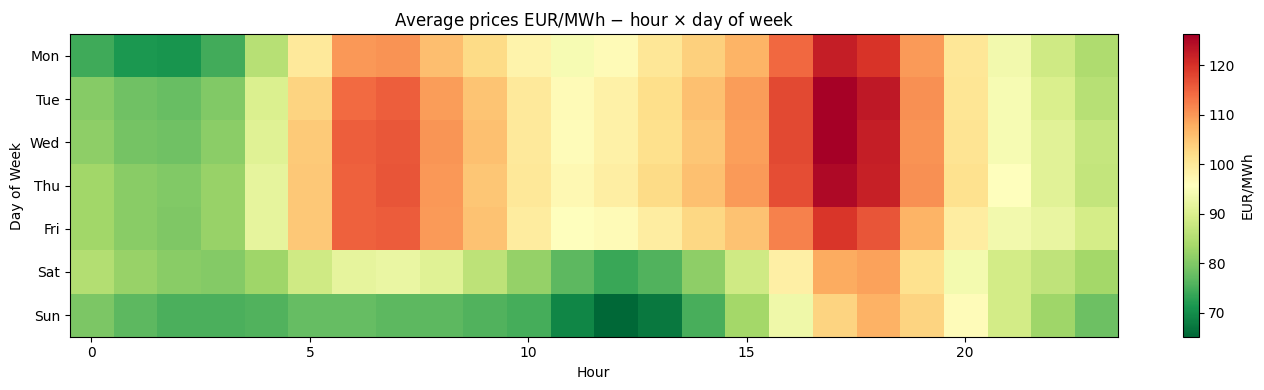

In [7]:
pivot = prices.groupby([prices.index.dayofweek, prices.index.hour]).mean().unstack()
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r")
ax.set_yticks(range(7))
ax.set_yticklabels(day_names)
ax.set_xlabel("Hour")
ax.set_ylabel("Day of Week")
ax.set_title("Average prices EUR/MWh $-$ hour $\\times$ day of week")
plt.colorbar(im, ax=ax, label="EUR/MWh")
plt.tight_layout()
plt.savefig('../data/processed/02_weekly_heatmap.png')

## Autocorrelation
Since a periodic behaviour was hilighted, a more robust estimate of such behaviour has to be conducted. It is important to figure out the main contributions to autocorrelation, in order to factor them out when trying to model energy prices as a stationary system (e.g. using SARIMA models).

To describe autocorrelation, we use the functions `plot_acf` and `plot_pacf` from `statsmodels`, which scan for correlations up to a given lag.

The function `plot_acf` displays the Autocorrelation coefficient $r_k$ defined as follows.

$$r_k = \frac{\sum_{t=k+1}^{T} (y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=k+1}^{T} (y_t - \bar{y})^2}$$

Where $T$ is the length of the time series, $k$ is the lag, and $y_t$ is the value of the series at time $t$. It is a measure of the correlation between data that are divided by $k$ timesteps. In our case we're expecting great correlations for prices that are 12 (i.e. 12 hours), 24 (i.e. a day) and 168 (i.e. a week) steps apart.

The function `plot_pacf`, on the other hand, display the Partial Autocorrelation coefficient $p_k$.

$$p_k = \frac{\mathrm{Cov}([y_t | y_{t-1} ... y_{t-k+1}], [y_{t-1} | y_{t-2} ... y_{t-k+1}])}{\sigma(y_t | y_{t-1} ... y_{t-k+1})
\times \sigma(y_{t-1} | y_{t-2} ... y_{t-k+1})}$$

The coefficient $p_k$ does not only describe the correlation between data divided by $k$ timesteps, but does so eliminating any contribution from smaller lags. This measure should be able to better recognize the actual characteristic frequencies of the system. In our example, there is a clear correlation at 24 hour lags due to the day-night cycle. Such correlation is observed also for 48 hour lags, yet there is no new phenomenon that explains a 2-days period autocorrelation in our system, but there is a reasonable 7-days mechanism influencing our data, which is indipendent on the day-night cycle, as described before.

ACF propagates the 24-hours lag correlation to any n-days lag, while PACF purposely avoids doing so.

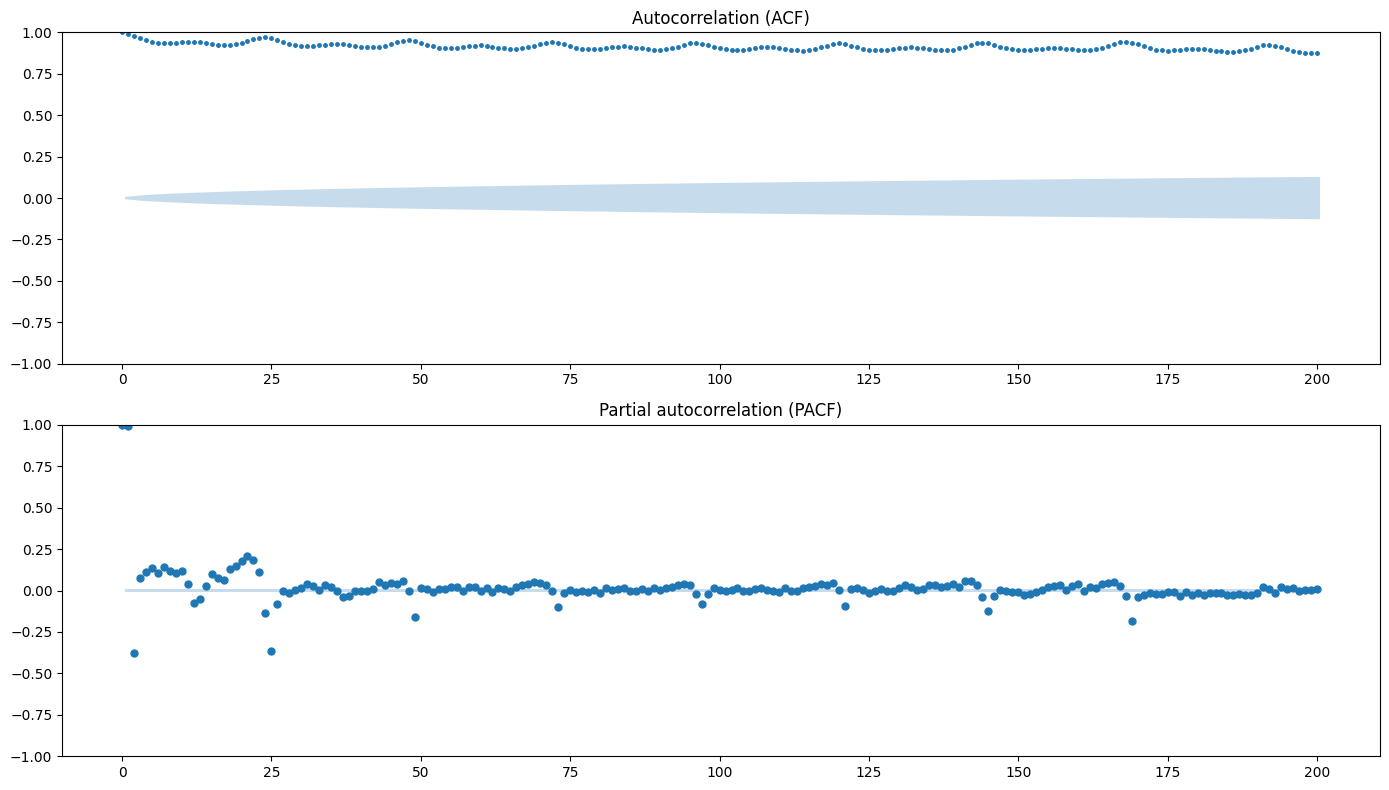

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14,8))

plot_acf(prices.dropna(), lags=200, ax=axes[0], alpha=0.05, use_vlines=False, marker='.')
axes[0].set_title("Autocorrelation (ACF)")
plot_pacf(prices.dropna(), lags=200, ax=axes[1], alpha=0.05, use_vlines=False)
axes[1].set_title("Partial autocorrelation (PACF)")
plt.tight_layout()
plt.savefig('../data/processed/02_autocorrelation.png')

The ACF plot highlights autocorrelation peaks every 24 hours, but $r_k$ stays high overall. Such behaviour is explained by the overall trend of prices and can be factored out by considering a differential timeseries. 

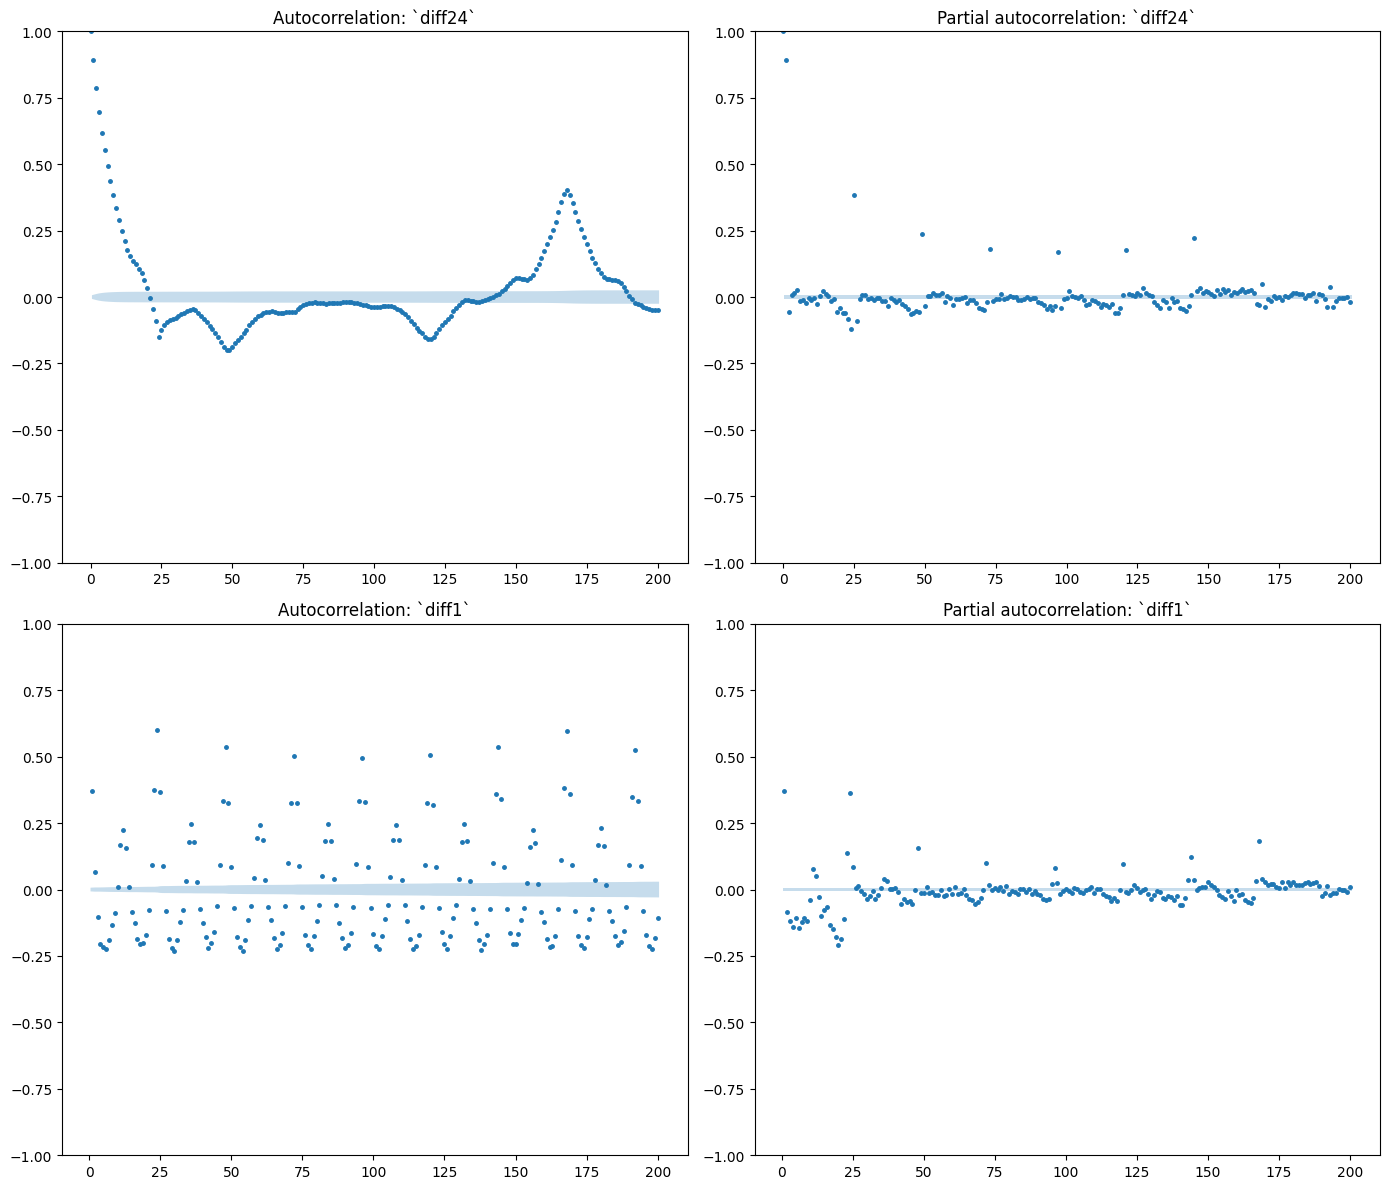

In [ ]:
price_diff_24 = prices.diff(24).dropna()
price_diff_1 = prices.diff(1).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14,12))

plot_acf(price_diff_24, lags=200, alpha=0.05, use_vlines=False, marker='.', ax=axes[0][0])
plot_pacf(price_diff_24, lags=200, alpha=0.05, use_vlines=False, marker='.', ax=axes[0][1])
plot_acf(price_diff_1, lags=200, alpha=0.05, use_vlines=False, zero=False, marker='.', ax=axes[1][0])
plot_pacf(price_diff_1, lags=200, alpha=0.05, use_vlines=False, zero=False, marker='.', ax=axes[1][1])

axes[0][0].set_title("Autocorrelation: `diff24`")
axes[0][1].set_title("Partial autocorrelation: `diff24`")
axes[1][0].set_title("Autocorrelation: `diff1`")
axes[1][1].set_title("Partial autocorrelation: `diff1`")

plt.tight_layout()
plt.savefig("../data/processed/02_autocorrelation_diff.png")

(Partial) Autocorrelation functions of differential timeseries highlight very sharp correlation peaks at 24 and 168 hours. An interesting behaviour is exhibited by 24-hours differential series at the 120-hours (i.e. 5 days) lag. Such autocorrelation is linked to working days and week-ends.

## Seasonal Decomoposition


To show how important these patterns are, one can try to decompose the observed data into a global trend and a seasonal contribution. This can be obtained with an additive model $Y[t]=T[t]+S[t]+e[t]$, or with a multiplicative model $Y[t]=T[t]\cdot S[t]\cdot e[t]$, where $Y[t]$ is the observed data at time $t$, $T[t]$ is the trend component, $S[t]$ is the seasonal contribution, and $e[t]$ is the error, or residue. The main difference between these two models is the behaviour of the seasonal contribution with respect to the magnitude of trend. In the additive model, greater values of trend leaves the seasonal contribution unaltered, which are instead amplified in a multiplicative model.

In [8]:
covid_lockdown = '2020-03-01'
weekly = prices.resample("W").mean()

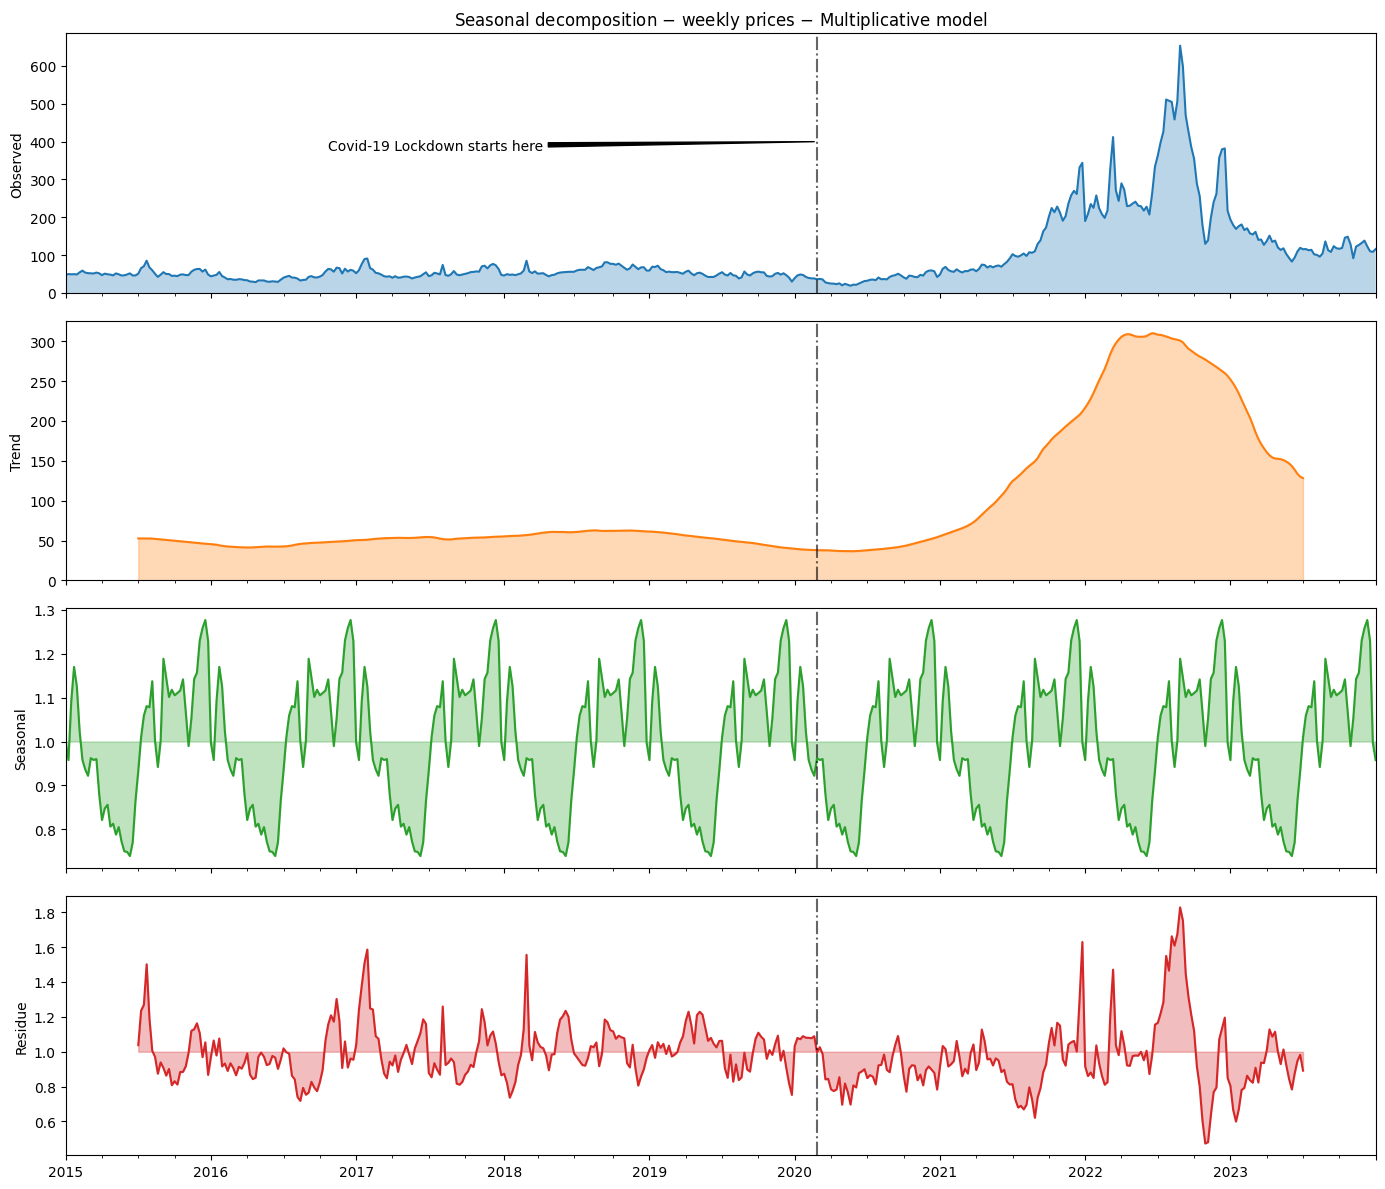

In [9]:
decomp_mul = seasonal_decompose(weekly.dropna(), model='multiplicative',
                            period=52
                            )

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
decomp_mul.observed.plot(ax=axes[0]); axes[0].set_ylabel("Observed")
axes[0].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[0].fill_between(decomp_mul.observed.index, decomp_mul.observed.values, alpha=0.3)
axes[0].set_ylim(0)

decomp_mul.trend.plot(ax=axes[1], color='C1'); axes[1].set_ylabel("Trend")
axes[1].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[1].fill_between(decomp_mul.trend.index, decomp_mul.trend.values, alpha=0.3, color='C1')
axes[1].set_ylim(0)

decomp_mul.seasonal.plot(ax=axes[2], color='C2'); axes[2].set_ylabel("Seasonal")
axes[2].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[2].fill_between(decomp_mul.seasonal.index, decomp_mul.seasonal.values, 1, alpha=0.3, color='C2')

decomp_mul.resid.plot(ax=axes[3], color='C3'); axes[3].set_ylabel("Residue")
axes[3].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[3].fill_between(decomp_mul.resid.index, decomp_mul.resid.values, 1, alpha=0.3, color='C3')


axes[0].set_title("Seasonal decomposition $-$ weekly prices $-$ Multiplicative model")
axes[0].annotate("Covid-19 Lockdown starts here", xy=(pd.Timestamp(covid_lockdown), 400), xytext=(0.2, 0.55), textcoords='axes fraction', arrowprops=dict(facecolor='black', arrowstyle='wedge'))
plt.tight_layout()
plt.savefig('../data/processed/02_seasonal_decomp_mult.png')

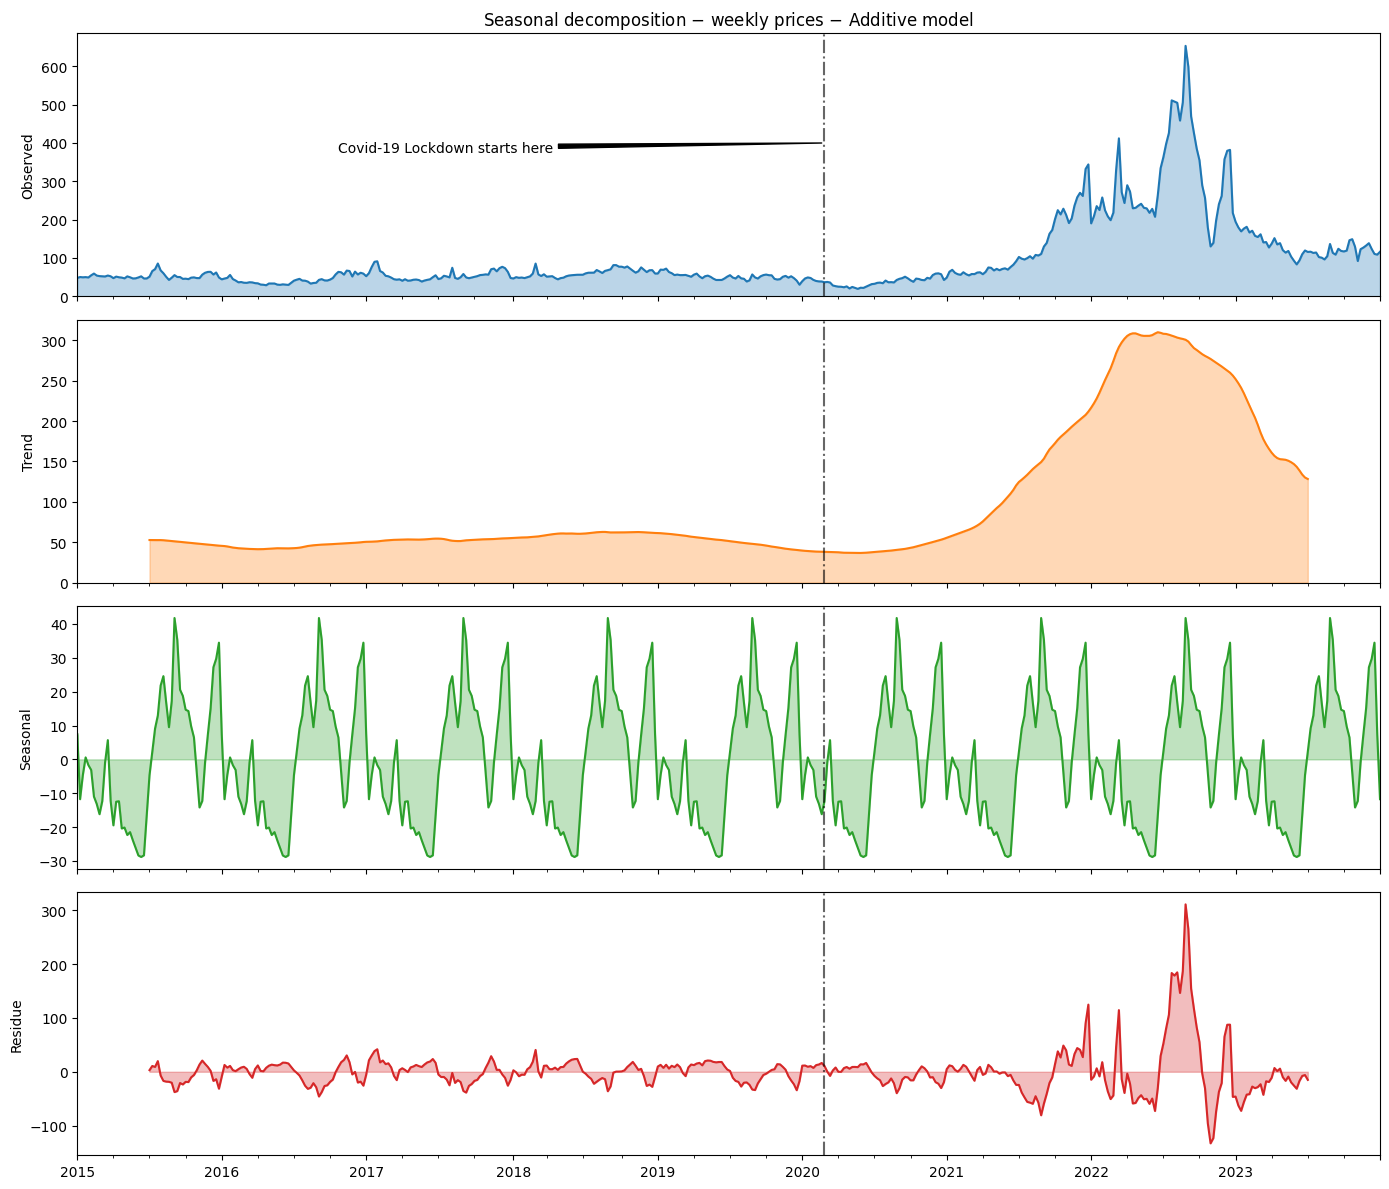

In [10]:
decomp = seasonal_decompose(weekly.dropna(), model='additive',
                            period=52
                            )

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
decomp.observed.plot(ax=axes[0]); axes[0].set_ylabel("Observed")
axes[0].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[0].fill_between(decomp.observed.index, decomp.observed.values, alpha=0.3, color='C0')
axes[0].set_ylim(0)

decomp.trend.plot(ax=axes[1], color='C1'); axes[1].set_ylabel("Trend")
axes[1].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[1].fill_between(decomp.trend.index, decomp.trend.values, alpha=0.3, color='C1')
axes[1].set_ylim(0)

decomp.seasonal.plot(ax=axes[2], color='C2'); axes[2].set_ylabel("Seasonal")
axes[2].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[2].fill_between(decomp.seasonal.index, decomp.seasonal.values, alpha=0.3, color='C2')

decomp.resid.plot(ax=axes[3], color='C3'); axes[3].set_ylabel("Residue")
axes[3].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[3].fill_between(decomp.resid.index, decomp.resid.values, alpha=0.3, color='C3')


axes[0].set_title("Seasonal decomposition $-$ weekly prices $-$ Additive model")
axes[0].annotate("Covid-19 Lockdown starts here", xy=(pd.Timestamp(covid_lockdown), 400), xytext=(0.2, 0.55), textcoords='axes fraction', arrowprops=dict(facecolor='black', arrowstyle='wedge'))
plt.tight_layout()
plt.savefig('../data/processed/02_seasonal_decomp_add.png')

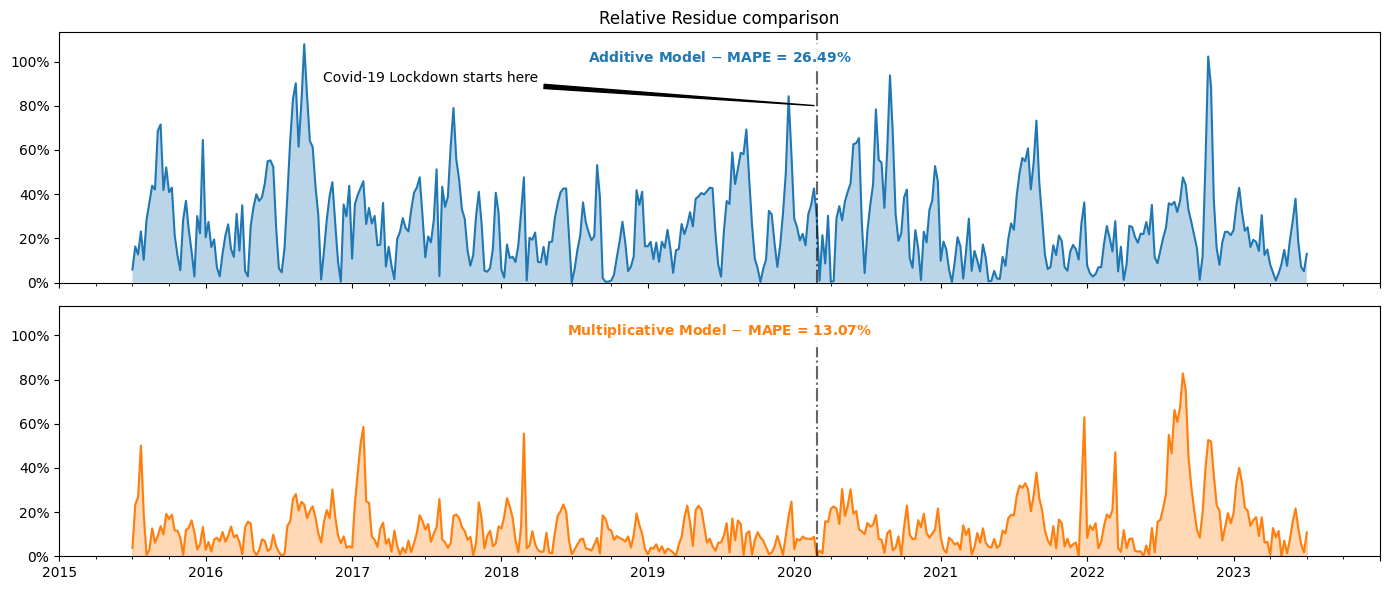

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14,6), sharex=True, sharey=True)

abs_relative_resid = abs(decomp.resid / decomp.observed)

abs_relative_resid.plot(ax=axes[0], color='C0')
axes[0].fill_between(abs_relative_resid.index, abs_relative_resid.values, alpha=0.3)
axes[0].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[0].set_ylim(0)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
abs(decomp_mul.resid-1).plot(ax=axes[1], color='C1')
axes[1].fill_between(abs_relative_resid.index, abs(decomp_mul.resid-1), alpha=0.3, color='C1')
axes[1].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[1].set_ylim(0)

axes[0].set_title("Relative Residue comparison")
axes[0].annotate("Covid-19 Lockdown starts here", xy=(pd.Timestamp(covid_lockdown), 0.8), xytext=(0.2, 0.8),
                 textcoords='axes fraction', arrowprops=dict(facecolor='black', arrowstyle='wedge'))
axes[0].annotate(f"Additive Model $-$ MAPE = {abs_relative_resid.mean():.2%}", xy=(0.5, 0.9), xycoords='axes fraction',
                 ha='center', va='center', color='C0', weight='semibold', bbox=dict(fc='white', ec='white', alpha=0.9))
axes[1].annotate(f"Multiplicative Model $-$ MAPE = {abs(decomp_mul.resid-1).mean():.2%}", xy=(0.5, 0.9), xycoords='axes fraction',
                 ha='center', va='center', color='C1', weight='semibold', bbox=dict(fc='white', ec='white', alpha=0.9))
plt.tight_layout()
plt.savefig('../data/processed/02_seasonal_decomp_comparison.png')

The multiplicative model seems to fit observed data better. Such behaviour is linked to greater price oscillations the greater the average price is. This may be due to the fact that demand gets sufficiently low (e.g. at nighttime or in the weekends) to drive prices down to the structural minimum.

The seasonal decomposition performed by `seasonal_decompose` is considered naive, as it only allows a fixed seasonal behaviour. STL (Seasonal-Trend decomposition using LOESS) uses LOESS local regression to estimate the periodic behaviour dinamically.

In [12]:
from statsmodels.tsa.seasonal import STL

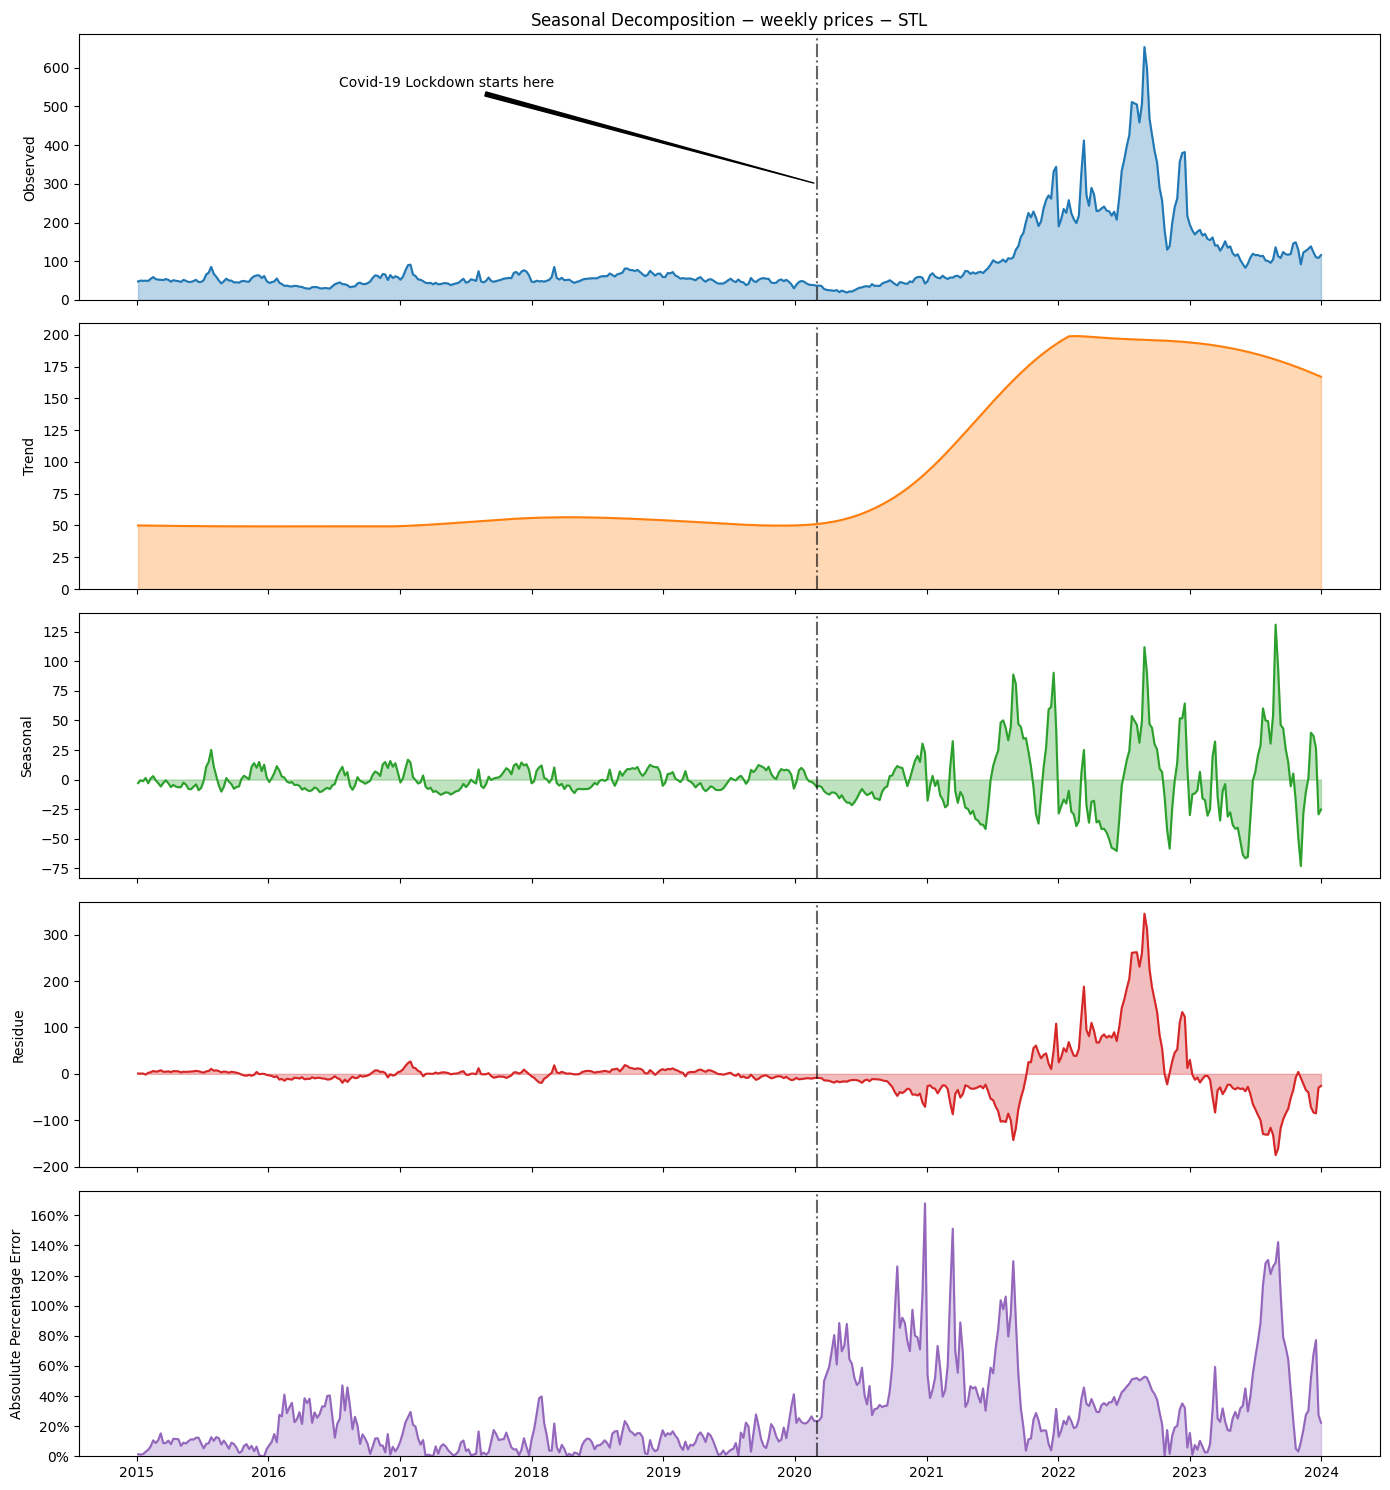

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(14,15), sharex=True)

stl_decomp = STL(weekly, period=52, seasonal=5, trend=201).fit()

axes[0].plot(stl_decomp.observed); axes[0].set_ylabel("Observed")
axes[0].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[0].fill_between(stl_decomp.observed.index, stl_decomp.observed.squeeze(), alpha=0.3, color='C0')
axes[0].set_ylim(0)


axes[1].plot(stl_decomp.trend, color='C1'); axes[1].set_ylabel("Trend")
axes[1].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[1].fill_between(stl_decomp.trend.index, stl_decomp.trend.squeeze(), alpha=0.3, color='C1')
axes[1].set_ylim(0)

axes[2].plot(stl_decomp.seasonal, color='C2'); axes[2].set_ylabel("Seasonal")
axes[2].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[2].fill_between(stl_decomp.seasonal.index, stl_decomp.seasonal.squeeze(), 0, alpha=0.3, color='C2')

axes[3].plot(stl_decomp.resid, color='C3'); axes[3].set_ylabel("Residue")
axes[3].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[3].fill_between(stl_decomp.resid.index, stl_decomp.resid.squeeze(), 0, alpha=0.3, color='C3')

relative_resid = abs(stl_decomp.resid/(stl_decomp.resid + stl_decomp.seasonal + stl_decomp.trend)).squeeze()
axes[4].plot(relative_resid, color='C4'); axes[4].set_ylabel("Absoulute Percentage Error")
axes[4].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[4].axvline(x=pd.Timestamp(covid_lockdown), ls='-.', alpha=0.6, color='black')
axes[4].fill_between(relative_resid.index, relative_resid.squeeze(), 0, alpha=0.3, color='C4')
axes[4].set_ylim(0)

axes[0].set_title("Seasonal Decomposition $-$ weekly prices $-$ STL")
axes[0].annotate("Covid-19 Lockdown starts here", xy=(pd.Timestamp(covid_lockdown), 300), xytext=(0.2, 0.8), textcoords='axes fraction', arrowprops=dict(facecolor='black', arrowstyle='wedge'))
plt.tight_layout()
plt.savefig('../data/processed/02_seasonal_decomp_STL.png')

In [14]:
from matplotlib.patches import Patch

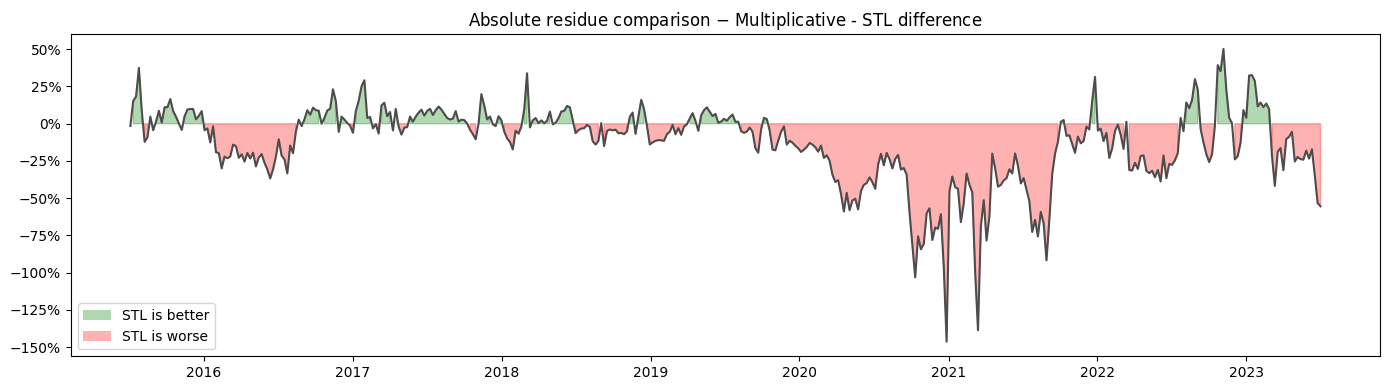

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(14,4))

comparison = abs(decomp_mul.resid - 1) - relative_resid
ax.plot(comparison, c='0.3')
ax.fill_between(comparison.index, comparison.values, where=comparison.values>0, color='green', alpha=0.3)
ax.fill_between(comparison.index, comparison.values, where=comparison.values<0, color='red', alpha=0.3)
ax.set_title("Absolute residue comparison $-$ Multiplicative - STL difference")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
# ax.annotate("Multiplicative beats STL", xy=(0.7, 0.5),xytext=(0.8,0.2), xycoords='axes fraction', textcoords='axes fraction',
            # arrowprops=dict(facecolor='black', arrowstyle='wedge'))
legend_elems = [Patch(facecolor='green', alpha=0.3, label='STL is better'),
                Patch(facecolor='red', alpha=0.3, label="STL is worse")]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.savefig('../data/processed/02_seasonal_decomp_comparison_STL.png')

Despite being able to dynamically adapt to different regimes, STL is worse than the naive multiplicative model at describing seasonality, especially during the gas crisis. This is explained by the additive nature of the STL model which, as shown above, is not suitable for energy prices. In order to achieve a multiplicative behaviour of the STL model it is possible to perform a transformation onto the timeseries (a Box-Cox transformation). A pure multiplicative model could be obtained with a logarithmic transformation of the data, but since electricity price can be zero, that is not feasible. These approaches are, however, beyond the purpose of an explorative data analysis and will not be used in this notebook.